# Prédiction du Churn Bancaire avec MLflow Tracking

## 🎯 Objectifs du Projet

Ce notebook présente un pipeline complet de machine learning pour prédire le churn (désabonnement) des clients bancaires en utilisant MLflow pour le tracking des expériences.

### Objectifs spécifiques :
- **Analyser** les données de churn bancaire
- **Préprocesser** les données avec des pipelines sklearn
- **Gérer** le déséquilibre des classes avec différentes stratégies
- **Entraîner** et **comparer** plusieurs modèles de ML
- **Tracker** les expériences avec MLflow
- **Sélectionner** automatiquement le meilleur modèle
- **Déployer** le modèle final pour la prédiction

### Méthodologie :
1. Exploration et nettoyage des données
2. Préparation avec pipelines de prétraitement
3. Test de 3 stratégies de gestion du déséquilibre
4. Entraînement de 3 modèles (LogisticRegression, RandomForest, XGBoost)
5. Tracking MLflow avec métriques et artefacts
6. Sélection automatique du meilleur modèle
7. Sauvegarde et démonstration

## 📦 Importations et Configuration de l'Environnement

In [3]:
# Importations des bibliothèques essentielles
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from pathlib import Path

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import xgboost as xgb

# Gestion du déséquilibre
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# MLflow pour le tracking
import mlflow
import mlflow.sklearn
import mlflow.xgboost

# Sauvegarde des modèles
import joblib

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Configuration MLflow
mlflow.set_tracking_uri("file:///c:/Users/saido/Desktop/customer-churn-mlflow-tracking/mlruns")
mlflow.set_experiment("Customer_Churn_Prediction")

print("✅ Toutes les bibliothèques ont été importées avec succès!")
print(f"📊 MLflow tracking URI: {mlflow.get_tracking_uri()}")
print(f"🧪 Expérience active: {mlflow.get_experiment_by_name('Customer_Churn_Prediction')}")

2025/11/01 11:06:25 INFO mlflow.tracking.fluent: Experiment with name 'Customer_Churn_Prediction' does not exist. Creating a new experiment.


✅ Toutes les bibliothèques ont été importées avec succès!
📊 MLflow tracking URI: file:///c:/Users/saido/Desktop/customer-churn-mlflow-tracking/mlruns
🧪 Expérience active: <Experiment: artifact_location='file:///c:/Users/saido/Desktop/customer-churn-mlflow-tracking/mlruns/715612044465910053', creation_time=1761991585766, experiment_id='715612044465910053', last_update_time=1761991585766, lifecycle_stage='active', name='Customer_Churn_Prediction', tags={}>


In [4]:
# Création des dossiers nécessaires
directories = ['../mlruns', '../models', '../reports']
for directory in directories:
    Path(directory).mkdir(parents=True, exist_ok=True)
    print(f"📁 Dossier créé/vérifié: {directory}")

print("\n🎯 Configuration terminée!")

📁 Dossier créé/vérifié: ../mlruns
📁 Dossier créé/vérifié: ../models
📁 Dossier créé/vérifié: ../reports

🎯 Configuration terminée!


## 📊 Chargement et Exploration des Données

In [5]:
# Chargement du dataset
data_path = "../data/dataset.csv"
df = pd.read_csv(data_path)

print("📈 Dataset chargé avec succès!")
print(f"📏 Dimensions: {df.shape}")
print(f"📋 Colonnes: {list(df.columns)}")
print(f"🎯 Variable cible 'Exited': {df['Exited'].value_counts().to_dict()}")

📈 Dataset chargé avec succès!
📏 Dimensions: (10000, 14)
📋 Colonnes: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
🎯 Variable cible 'Exited': {0: 7963, 1: 2037}


🔍 EXPLORATION RAPIDE DES DONNÉES

📊 Aperçu des premières lignes:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0



📈 Statistiques descriptives:


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000



❌ Valeurs manquantes par colonne:
Aucune valeur manquante détectée!

🎯 Distribution de la variable cible 'Exited':
Non-Churn (0): 7963 (79.6%)
Churn (1): 2037 (20.4%)


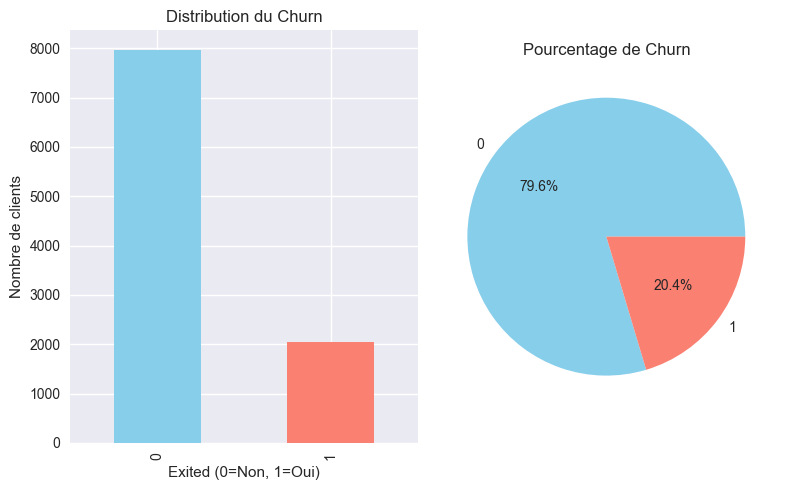

In [6]:
# EDA rapide
print("🔍 EXPLORATION RAPIDE DES DONNÉES")
print("="*50)

print(f"\n📊 Aperçu des premières lignes:")
display(df.head())

print(f"\n📈 Statistiques descriptives:")
display(df.describe())

print(f"\n❌ Valeurs manquantes par colonne:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "Aucune valeur manquante détectée!")

print(f"\n🎯 Distribution de la variable cible 'Exited':")
churn_distribution = df['Exited'].value_counts()
churn_percentage = df['Exited'].value_counts(normalize=True) * 100
print(f"Non-Churn (0): {churn_distribution[0]} ({churn_percentage[0]:.1f}%)")
print(f"Churn (1): {churn_distribution[1]} ({churn_percentage[1]:.1f}%)")

# Visualisation de la distribution de la cible
plt.figure(figsize=(8, 5))
plt.subplot(1, 2, 1)
df['Exited'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribution du Churn')
plt.xlabel('Exited (0=Non, 1=Oui)')
plt.ylabel('Nombre de clients')

plt.subplot(1, 2, 2)
df['Exited'].value_counts(normalize=True).plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'salmon'])
plt.title('Pourcentage de Churn')
plt.ylabel('')

plt.tight_layout()
plt.show()

## 🧹 Nettoyage et Préparation des Données

In [7]:
# Nettoyage des données selon les spécifications
print("🧹 NETTOYAGE DES DONNÉES")
print("="*40)

# Affichage des dimensions initiales
print(f"📏 Dimensions initiales: {df.shape}")

# 1. Suppression des colonnes non pertinentes
columns_to_drop = ['RowNumber', 'CustomerId', 'Surname']
df_clean = df.drop(columns=columns_to_drop)
print(f"❌ Colonnes supprimées: {columns_to_drop}")

# 2. Filtrage des âges > 80 ans
initial_count = len(df_clean)
df_clean = df_clean[df_clean['Age'] <= 80]
removed_count = initial_count - len(df_clean)
print(f"👴 Clients avec âge > 80 supprimés: {removed_count}")

# 3. Définition de la variable cible et séparation X/y
target = 'Exited'
y = df_clean[target]
X = df_clean.drop(columns=[target])

print(f"📏 Dimensions finales: {X.shape}")
print(f"🎯 Variable cible: {target}")
print(f"📊 Features: {list(X.columns)}")
print(f"✅ Distribution finale du churn: {y.value_counts().to_dict()}")

# Vérification des types de données
print(f"\n📋 Types de données:")
print(X.dtypes)

🧹 NETTOYAGE DES DONNÉES
📏 Dimensions initiales: (10000, 14)
❌ Colonnes supprimées: ['RowNumber', 'CustomerId', 'Surname']
👴 Clients avec âge > 80 supprimés: 12
📏 Dimensions finales: (9988, 10)
🎯 Variable cible: Exited
📊 Features: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
✅ Distribution finale du churn: {0: 7952, 1: 2036}

📋 Types de données:
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
dtype: object


## 🔄 Split Train/Test et Pipelines de Prétraitement

In [8]:
# Split train/test avec stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print("🔄 SPLIT TRAIN/TEST")
print("="*30)
print(f"📊 Train set: {X_train.shape}")
print(f"📊 Test set: {X_test.shape}")
print(f"🎯 Distribution train: {y_train.value_counts().to_dict()}")
print(f"🎯 Distribution test: {y_test.value_counts().to_dict()}")

# Détection automatique des colonnes numériques et catégorielles
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

print(f"\n📈 Colonnes numériques ({len(numeric_features)}): {numeric_features}")
print(f"📝 Colonnes catégorielles ({len(categorical_features)}): {categorical_features}")

🔄 SPLIT TRAIN/TEST
📊 Train set: (7990, 10)
📊 Test set: (1998, 10)
🎯 Distribution train: {0: 6361, 1: 1629}
🎯 Distribution test: {0: 1591, 1: 407}

📈 Colonnes numériques (8): ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
📝 Colonnes catégorielles (2): ['Geography', 'Gender']


In [9]:
# Création des pipelines de prétraitement
print("🔧 CRÉATION DES PIPELINES DE PRÉTRAITEMENT")
print("="*45)

# Pipeline pour les variables numériques
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # Imputation par la médiane
    ('scaler', StandardScaler())  # Standardisation
])

# Pipeline pour les variables catégorielles
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Imputation par la valeur la plus fréquente
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))  # One-Hot Encoding
])

# Combinaison via ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

print("✅ Pipeline numérique: Imputation médiane + Standardisation")
print("✅ Pipeline catégoriel: Imputation mode + OneHotEncoder")
print("✅ ColumnTransformer créé pour combiner les pipelines")

# Test du préprocesseur
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"\n📊 Dimensions après prétraitement:")
print(f"   Train: {X_train_processed.shape}")
print(f"   Test: {X_test_processed.shape}")

🔧 CRÉATION DES PIPELINES DE PRÉTRAITEMENT
✅ Pipeline numérique: Imputation médiane + Standardisation
✅ Pipeline catégoriel: Imputation mode + OneHotEncoder
✅ ColumnTransformer créé pour combiner les pipelines

📊 Dimensions après prétraitement:
   Train: (7990, 11)
   Test: (1998, 11)


## ⚖️ Gestion du Déséquilibre des Classes

Nous allons tester trois stratégies pour gérer le déséquilibre des classes :
1. **Baseline** : Aucune correction du déséquilibre
2. **Class Weight** : Pondération automatique des classes
3. **SMOTE** : Suréchantillonnage synthétique (appliqué uniquement sur le train)

In [10]:
# Configuration des stratégies de gestion du déséquilibre
print("⚖️ CONFIGURATION DES STRATÉGIES DE DÉSÉQUILIBRE")
print("="*50)

# Stratégie 1: Baseline (aucune correction)
baseline_config = {
    'name': 'Baseline',
    'description': 'Aucune correction du déséquilibre',
    'use_smote': False,
    'class_weight': None
}

# Stratégie 2: Class Weight (pondération automatique)
class_weight_config = {
    'name': 'Class_Weight',
    'description': 'Pondération automatique des classes',
    'use_smote': False,
    'class_weight': 'balanced'
}

# Stratégie 3: SMOTE (suréchantillonnage synthétique)
smote_config = {
    'name': 'SMOTE',
    'description': 'Suréchantillonnage synthétique',
    'use_smote': True,
    'class_weight': None
}

# Liste des stratégies
imbalance_strategies = [baseline_config, class_weight_config, smote_config]

for strategy in imbalance_strategies:
    print(f"✅ {strategy['name']}: {strategy['description']}")

print(f"\n📊 Distribution actuelle du train:")
print(f"   Classe 0 (Non-Churn): {(y_train == 0).sum()} ({(y_train == 0).mean()*100:.1f}%)")
print(f"   Classe 1 (Churn): {(y_train == 1).sum()} ({(y_train == 1).mean()*100:.1f}%)")

⚖️ CONFIGURATION DES STRATÉGIES DE DÉSÉQUILIBRE
✅ Baseline: Aucune correction du déséquilibre
✅ Class_Weight: Pondération automatique des classes
✅ SMOTE: Suréchantillonnage synthétique

📊 Distribution actuelle du train:
   Classe 0 (Non-Churn): 6361 (79.6%)
   Classe 1 (Churn): 1629 (20.4%)


## 🤖 Entraînement des Modèles avec MLflow Tracking

In [11]:
# Configuration des modèles
models_config = {
    'LogisticRegression': {
        'model': LogisticRegression(random_state=42, max_iter=1000),
        'params': {'random_state': 42, 'max_iter': 1000}
    },
    'RandomForest': {
        'model': RandomForestClassifier(random_state=42, n_estimators=100),
        'params': {'random_state': 42, 'n_estimators': 100}
    },
    'XGBoost': {
        'model': xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
        'params': {'random_state': 42, 'eval_metric': 'logloss'}
    }
}

print("🤖 CONFIGURATION DES MODÈLES")
print("="*35)
for model_name, config in models_config.items():
    print(f"✅ {model_name}: {config['params']}")

# Fonction pour créer les pipelines selon la stratégie
def create_pipeline(model, strategy_config, preprocessor):
    """Crée un pipeline selon la stratégie de déséquilibre"""
    
    if strategy_config['use_smote']:
        # Pipeline avec SMOTE (imblearn)
        pipeline = ImbPipeline([
            ('preprocessor', preprocessor),
            ('smote', SMOTE(random_state=42)),
            ('model', model)
        ])
    else:
        # Pipeline standard (sklearn)
        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('model', model)
        ])
    
    return pipeline

print("\n🔧 Fonction de création de pipeline définie!")

🤖 CONFIGURATION DES MODÈLES
✅ LogisticRegression: {'random_state': 42, 'max_iter': 1000}
✅ RandomForest: {'random_state': 42, 'n_estimators': 100}
✅ XGBoost: {'random_state': 42, 'eval_metric': 'logloss'}

🔧 Fonction de création de pipeline définie!


In [12]:
# Fonction pour sauvegarder les artefacts (matrices de confusion et courbes ROC)
def save_artifacts(y_true, y_pred, y_pred_proba, model_name, strategy_name):
    """Sauvegarde les artefacts MLflow (confusion matrix et ROC curve)"""
    
    # Matrice de confusion
    plt.figure(figsize=(12, 5))
    
    # Subplot 1: Confusion Matrix
    plt.subplot(1, 2, 1)
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Non-Churn', 'Churn'],
                yticklabels=['Non-Churn', 'Churn'])
    plt.title(f'Matrice de Confusion\n{model_name} - {strategy_name}')
    plt.xlabel('Prédictions')
    plt.ylabel('Réalité')
    
    # Subplot 2: ROC Curve
    plt.subplot(1, 2, 2)
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    auc_score = roc_auc_score(y_true, y_pred_proba)
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlabel('Taux de Faux Positifs')
    plt.ylabel('Taux de Vrais Positifs')
    plt.title(f'Courbe ROC\n{model_name} - {strategy_name}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Sauvegarde
    artifact_path = f"../reports/{model_name}_{strategy_name}_metrics.png"
    plt.savefig(artifact_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    return artifact_path

print("📊 Fonction de sauvegarde des artefacts définie!")

📊 Fonction de sauvegarde des artefacts définie!


🚀 ENTRAÎNEMENT ET TRACKING MLFLOW

📋 Stratégie: Baseline - Aucune correction du déséquilibre
------------------------------------------------------------

🤖 Modèle: LogisticRegression


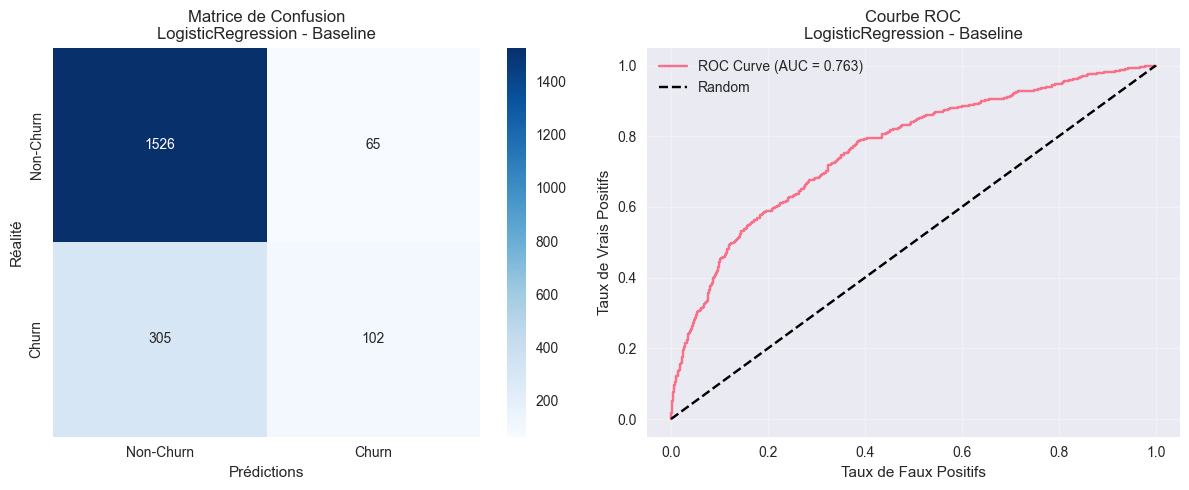

2025/11/01 11:06:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/01 11:06:46 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


   ✅ Accuracy: 0.8148
   ✅ F1-Score: 0.3554
   ✅ ROC-AUC: 0.7632

🤖 Modèle: RandomForest


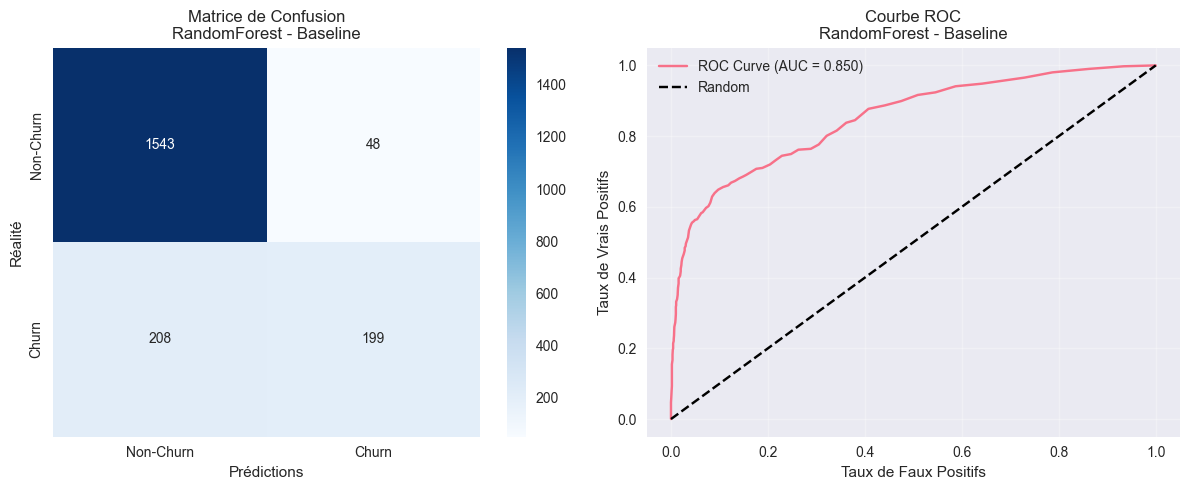

2025/11/01 11:06:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/01 11:06:57 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


   ✅ Accuracy: 0.8719
   ✅ F1-Score: 0.6086
   ✅ ROC-AUC: 0.8498

🤖 Modèle: XGBoost


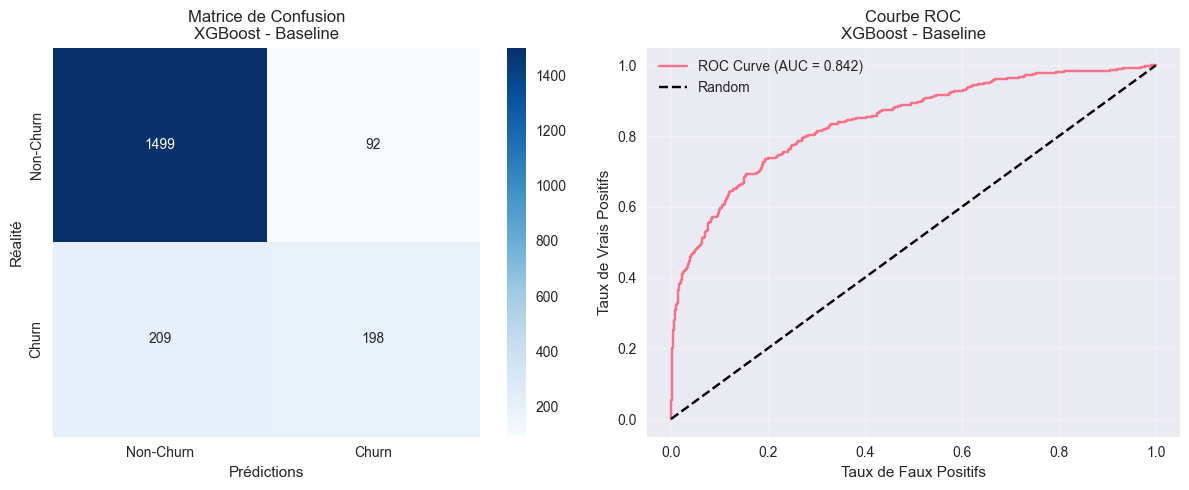

2025/11/01 11:06:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


   ❌ Erreur: 'Pipeline' object has no attribute 'save_model'

📋 Stratégie: Class_Weight - Pondération automatique des classes
------------------------------------------------------------

🤖 Modèle: LogisticRegression


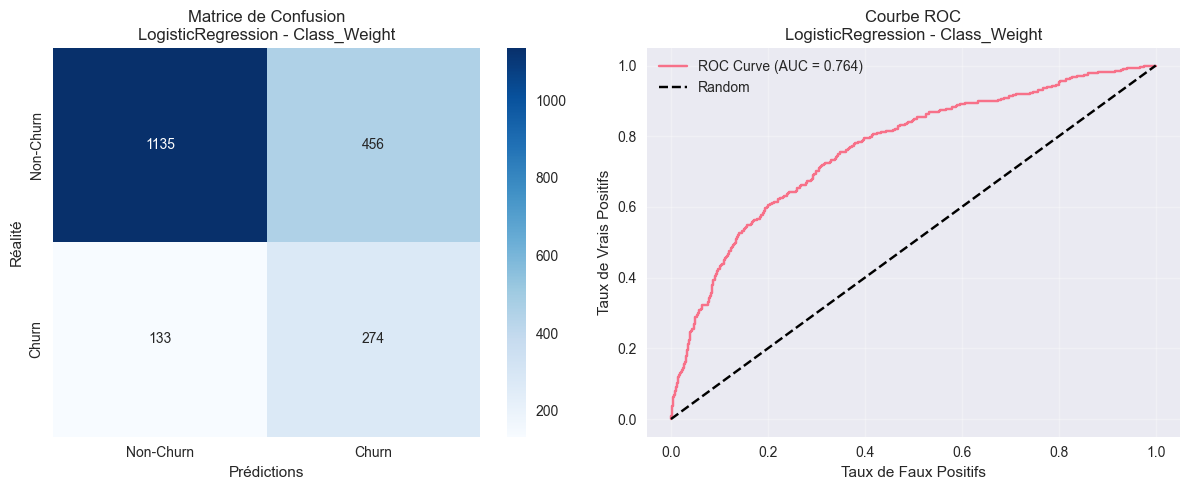

2025/11/01 11:07:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/01 11:07:09 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


   ✅ Accuracy: 0.7052
   ✅ F1-Score: 0.4820
   ✅ ROC-AUC: 0.7641

🤖 Modèle: RandomForest


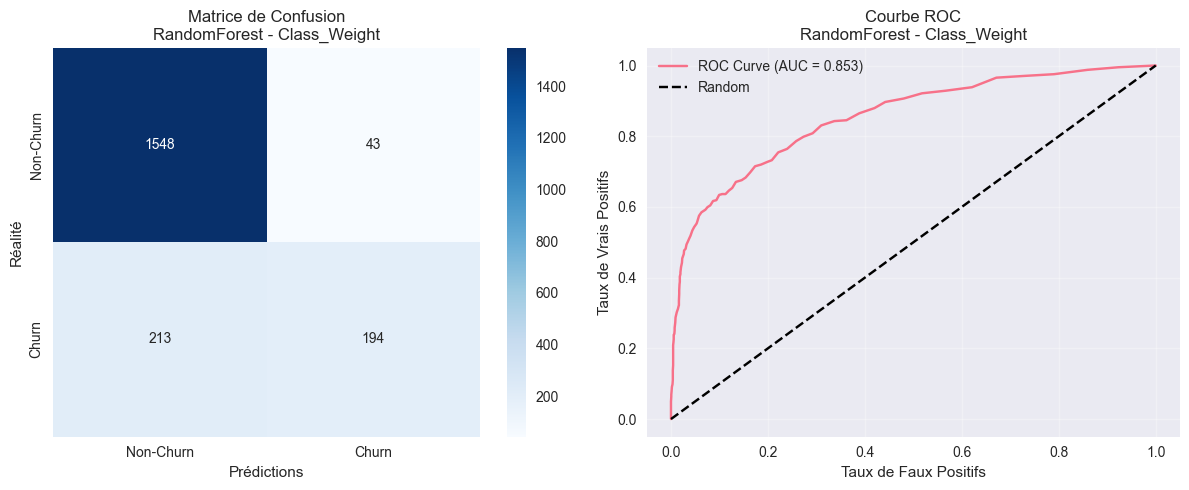

2025/11/01 11:07:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/01 11:07:20 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


   ✅ Accuracy: 0.8719
   ✅ F1-Score: 0.6025
   ✅ ROC-AUC: 0.8531

🤖 Modèle: XGBoost


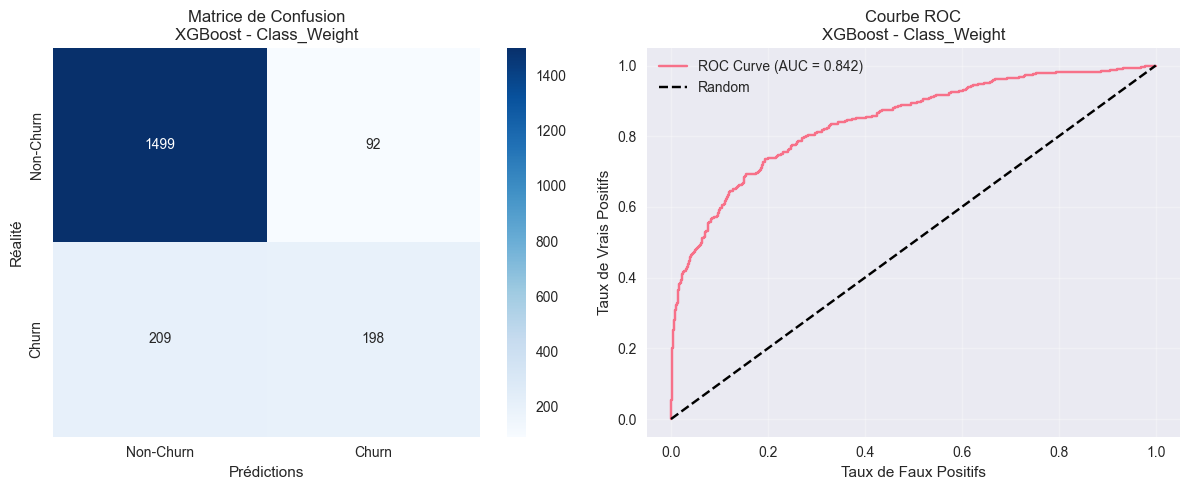

2025/11/01 11:07:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


   ❌ Erreur: 'Pipeline' object has no attribute 'save_model'

📋 Stratégie: SMOTE - Suréchantillonnage synthétique
------------------------------------------------------------

🤖 Modèle: LogisticRegression


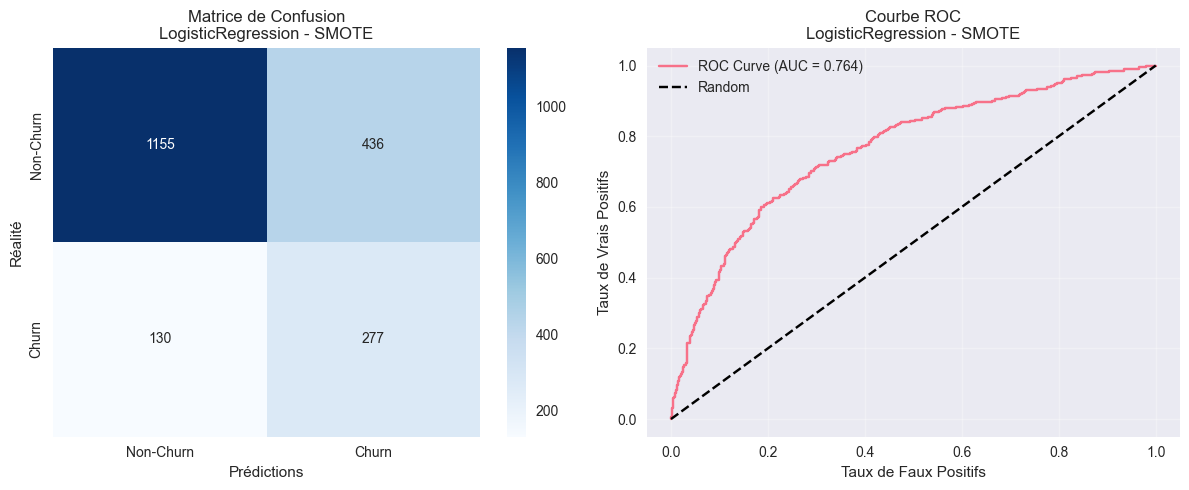

2025/11/01 11:07:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/01 11:07:34 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


   ✅ Accuracy: 0.7167
   ✅ F1-Score: 0.4946
   ✅ ROC-AUC: 0.7637

🤖 Modèle: RandomForest


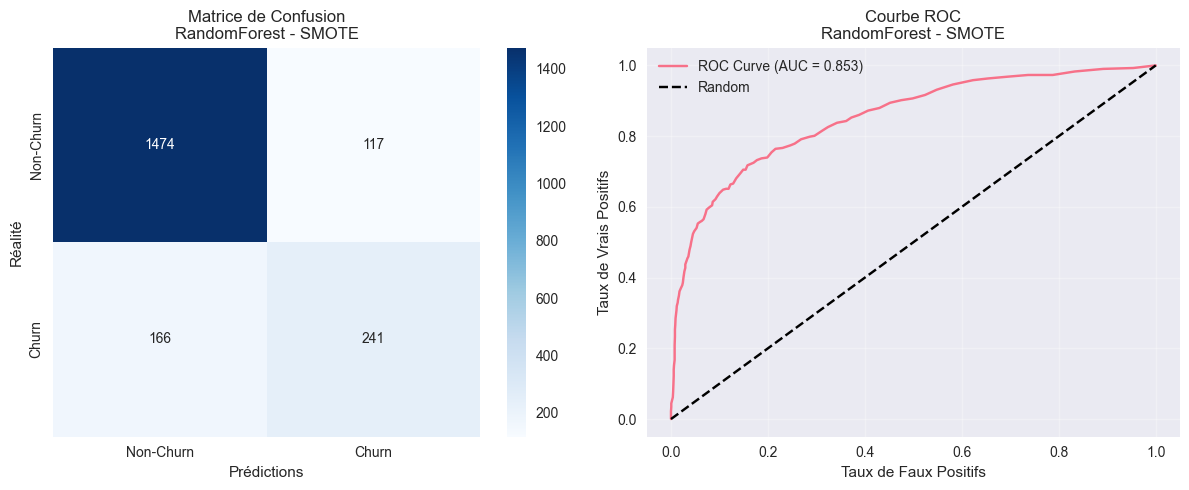

2025/11/01 11:07:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/01 11:07:48 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


   ✅ Accuracy: 0.8584
   ✅ F1-Score: 0.6301
   ✅ ROC-AUC: 0.8526

🤖 Modèle: XGBoost


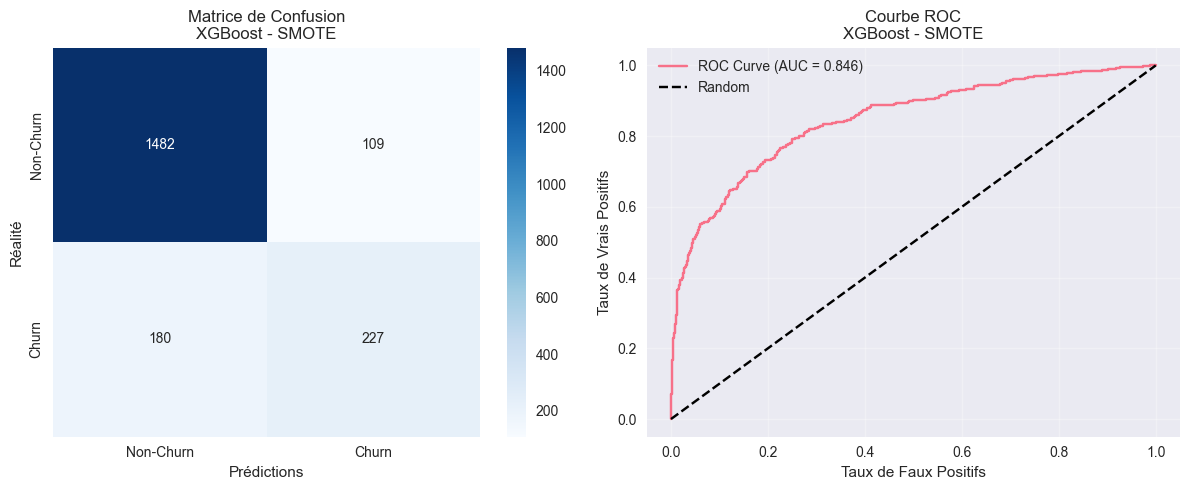

2025/11/01 11:07:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


   ❌ Erreur: 'Pipeline' object has no attribute 'save_model'

🎉 Entraînement terminé! 6 modèles entraînés avec succès.


In [13]:
# Entraînement et tracking MLflow de tous les modèles
results = []

print("🚀 ENTRAÎNEMENT ET TRACKING MLFLOW")
print("="*40)

for strategy in imbalance_strategies:
    strategy_name = strategy['name']
    print(f"\n📋 Stratégie: {strategy_name} - {strategy['description']}")
    print("-" * 60)
    
    for model_name, model_config in models_config.items():
        print(f"\n🤖 Modèle: {model_name}")
        
        with mlflow.start_run(run_name=f"{model_name}_{strategy_name}"):
            try:
                # Création du modèle avec class_weight si nécessaire
                model = model_config['model']
                if strategy['class_weight'] and hasattr(model, 'class_weight'):
                    model.set_params(class_weight=strategy['class_weight'])
                
                # Création du pipeline
                pipeline = create_pipeline(model, strategy, preprocessor)
                
                # Entraînement
                pipeline.fit(X_train, y_train)
                
                # Prédictions
                y_pred = pipeline.predict(X_test)
                y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
                
                # Calcul des métriques
                accuracy = accuracy_score(y_test, y_pred)
                f1 = f1_score(y_test, y_pred)
                roc_auc = roc_auc_score(y_test, y_pred_proba)
                
                # Logging des paramètres
                mlflow.log_param("model_type", model_name)
                mlflow.log_param("imbalance_strategy", strategy_name)
                mlflow.log_param("use_smote", strategy['use_smote'])
                mlflow.log_param("class_weight", strategy['class_weight'])
                
                # Logging des hyperparamètres du modèle
                for param_name, param_value in model_config['params'].items():
                    mlflow.log_param(f"model_{param_name}", param_value)
                
                # Logging des métriques
                mlflow.log_metric("accuracy", accuracy)
                mlflow.log_metric("f1_score", f1)
                mlflow.log_metric("roc_auc", roc_auc)
                
                # Sauvegarde des artefacts
                artifact_path = save_artifacts(y_test, y_pred, y_pred_proba, model_name, strategy_name)
                mlflow.log_artifact(artifact_path)
                
                # Logging du modèle
                if model_name == "XGBoost":
                    mlflow.xgboost.log_model(pipeline, "model")
                else:
                    mlflow.sklearn.log_model(pipeline, "model")
                
                # Stockage des résultats
                results.append({
                    'Model': model_name,
                    'Strategy': strategy_name,
                    'Accuracy': accuracy,
                    'F1_Score': f1,
                    'ROC_AUC': roc_auc,
                    'Pipeline': pipeline
                })
                
                print(f"   ✅ Accuracy: {accuracy:.4f}")
                print(f"   ✅ F1-Score: {f1:.4f}")
                print(f"   ✅ ROC-AUC: {roc_auc:.4f}")
                
            except Exception as e:
                print(f"   ❌ Erreur: {str(e)}")
                mlflow.log_param("error", str(e))

print(f"\n🎉 Entraînement terminé! {len(results)} modèles entraînés avec succès.")

## 📊 Comparaison des Résultats et Sélection du Meilleur Modèle

In [14]:
# Création du DataFrame de comparaison
results_df = pd.DataFrame(results)
results_df = results_df.drop('Pipeline', axis=1)  # Retirer la colonne Pipeline pour l'affichage

print("📊 COMPARAISON DES RÉSULTATS")
print("="*35)
print("\n📋 Tableau de comparaison des modèles:")
display(results_df.round(4))

# Tri par F1-Score puis par Accuracy pour sélection automatique
results_df_sorted = results_df.sort_values(['F1_Score', 'Accuracy'], ascending=False)

print(f"\n🏆 CLASSEMENT DES MODÈLES (par F1-Score puis Accuracy):")
print("-" * 60)
for i, (idx, row) in enumerate(results_df_sorted.iterrows(), 1):
    print(f"{i}. {row['Model']} - {row['Strategy']}")
    print(f"   F1: {row['F1_Score']:.4f} | Accuracy: {row['Accuracy']:.4f} | ROC-AUC: {row['ROC_AUC']:.4f}")

# Sélection automatique du meilleur modèle
best_result = results_df_sorted.iloc[0]
best_model_name = best_result['Model']
best_strategy = best_result['Strategy']

# Récupération du pipeline correspondant
best_pipeline = None
for result in results:
    if result['Model'] == best_model_name and result['Strategy'] == best_strategy:
        best_pipeline = result['Pipeline']
        break

print(f"\n🥇 MEILLEUR MODÈLE SÉLECTIONNÉ:")
print(f"   Modèle: {best_model_name}")
print(f"   Stratégie: {best_strategy}")
print(f"   F1-Score: {best_result['F1_Score']:.4f}")
print(f"   Accuracy: {best_result['Accuracy']:.4f}")
print(f"   ROC-AUC: {best_result['ROC_AUC']:.4f}")

📊 COMPARAISON DES RÉSULTATS

📋 Tableau de comparaison des modèles:


,Model,Strategy,Accuracy,F1_Score,ROC_AUC
0,LogisticRegression,Baseline,0.8148,0.3554,0.7632
1,RandomForest,Baseline,0.8719,0.6086,0.8498
2,LogisticRegression,Class_Weight,0.7052,0.4820,0.7641
3,RandomForest,Class_Weight,0.8719,0.6025,0.8531
4,LogisticRegression,SMOTE,0.7167,0.4946,0.7637
5,RandomForest,SMOTE,0.8584,0.6301,0.8526



🏆 CLASSEMENT DES MODÈLES (par F1-Score puis Accuracy):
------------------------------------------------------------
1. RandomForest - SMOTE
   F1: 0.6301 | Accuracy: 0.8584 | ROC-AUC: 0.8526
2. RandomForest - Baseline
   F1: 0.6086 | Accuracy: 0.8719 | ROC-AUC: 0.8498
3. RandomForest - Class_Weight
   F1: 0.6025 | Accuracy: 0.8719 | ROC-AUC: 0.8531
4. LogisticRegression - SMOTE
   F1: 0.4946 | Accuracy: 0.7167 | ROC-AUC: 0.7637
5. LogisticRegression - Class_Weight
   F1: 0.4820 | Accuracy: 0.7052 | ROC-AUC: 0.7641
6. LogisticRegression - Baseline
   F1: 0.3554 | Accuracy: 0.8148 | ROC-AUC: 0.7632

🥇 MEILLEUR MODÈLE SÉLECTIONNÉ:
   Modèle: RandomForest
   Stratégie: SMOTE
   F1-Score: 0.6301
   Accuracy: 0.8584
   ROC-AUC: 0.8526


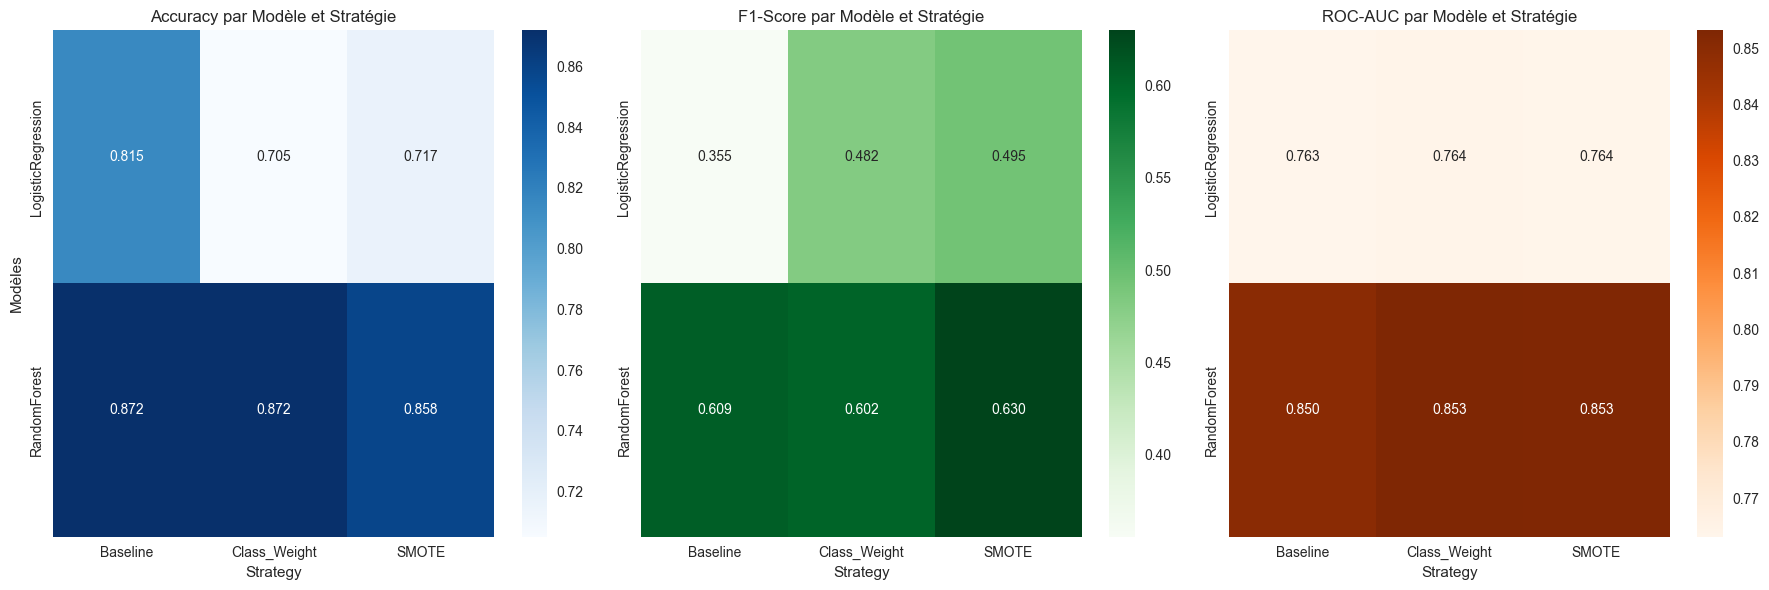

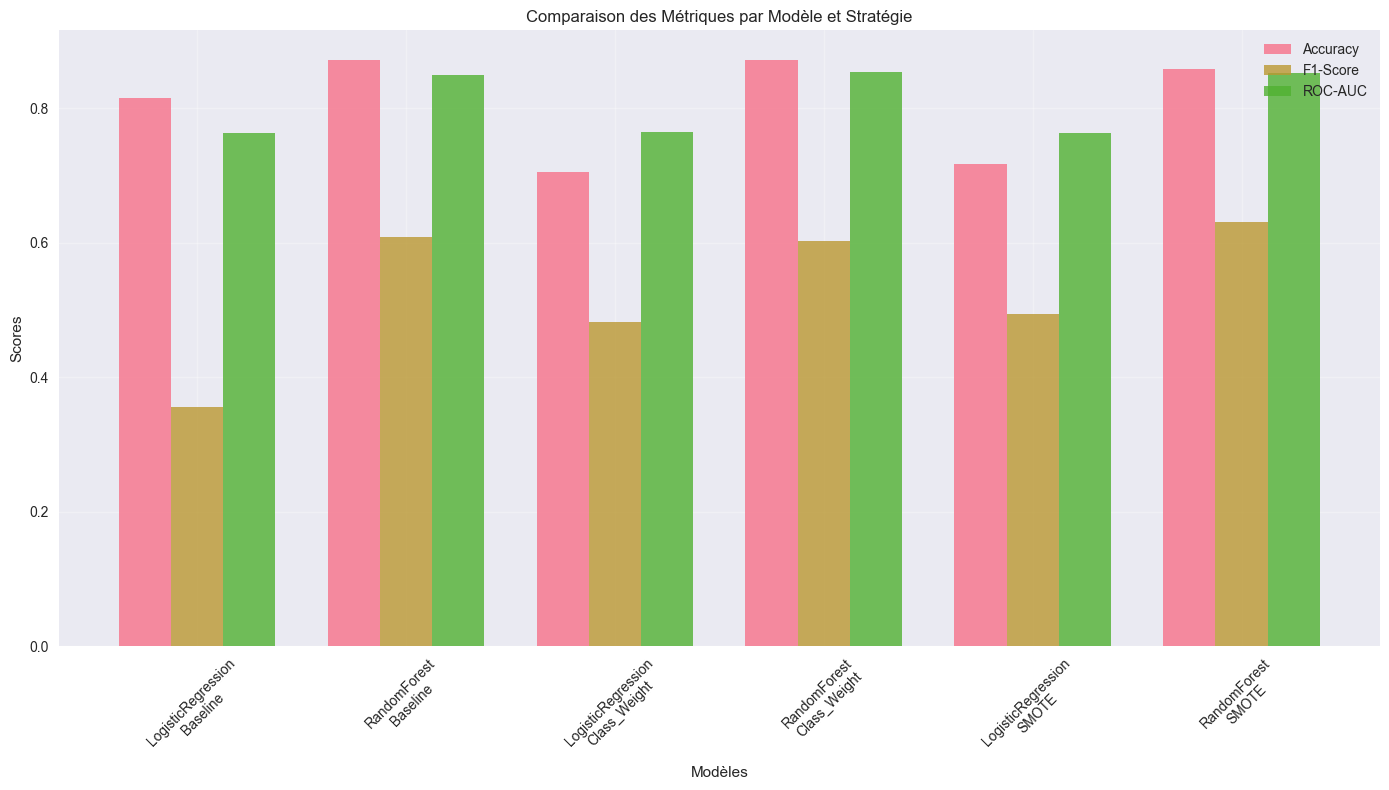

In [15]:
# Visualisation comparative des résultats
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Graphique 1: Accuracy par modèle et stratégie
pivot_accuracy = results_df.pivot(index='Model', columns='Strategy', values='Accuracy')
sns.heatmap(pivot_accuracy, annot=True, fmt='.3f', cmap='Blues', ax=axes[0])
axes[0].set_title('Accuracy par Modèle et Stratégie')
axes[0].set_ylabel('Modèles')

# Graphique 2: F1-Score par modèle et stratégie
pivot_f1 = results_df.pivot(index='Model', columns='Strategy', values='F1_Score')
sns.heatmap(pivot_f1, annot=True, fmt='.3f', cmap='Greens', ax=axes[1])
axes[1].set_title('F1-Score par Modèle et Stratégie')
axes[1].set_ylabel('')

# Graphique 3: ROC-AUC par modèle et stratégie
pivot_auc = results_df.pivot(index='Model', columns='Strategy', values='ROC_AUC')
sns.heatmap(pivot_auc, annot=True, fmt='.3f', cmap='Oranges', ax=axes[2])
axes[2].set_title('ROC-AUC par Modèle et Stratégie')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

# Graphique en barres pour comparaison directe
fig, ax = plt.subplots(figsize=(14, 8))
x = range(len(results_df))
width = 0.25

ax.bar([i - width for i in x], results_df['Accuracy'], width, label='Accuracy', alpha=0.8)
ax.bar(x, results_df['F1_Score'], width, label='F1-Score', alpha=0.8)
ax.bar([i + width for i in x], results_df['ROC_AUC'], width, label='ROC-AUC', alpha=0.8)

ax.set_xlabel('Modèles')
ax.set_ylabel('Scores')
ax.set_title('Comparaison des Métriques par Modèle et Stratégie')
ax.set_xticks(x)
ax.set_xticklabels([f"{row['Model']}\n{row['Strategy']}" for _, row in results_df.iterrows()], rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 💾 Sauvegarde du Meilleur Modèle

In [16]:
# Ré-entraînement du meilleur pipeline complet
print("💾 SAUVEGARDE DU MEILLEUR MODÈLE")
print("="*40)

if best_pipeline is not None:
    # Ré-entraînement sur l'ensemble complet des données d'entraînement
    print(f"🔄 Ré-entraînement du meilleur modèle: {best_model_name} - {best_strategy}")
    best_pipeline.fit(X_train, y_train)
    
    # Sauvegarde locale avec joblib
    model_path = "../models/best_model.pkl"
    joblib.dump(best_pipeline, model_path)
    
    print(f"✅ Modèle sauvegardé dans: {model_path}")
    
    # Sauvegarde des métadonnées du modèle
    model_metadata = {
        'model_name': best_model_name,
        'strategy': best_strategy,
        'f1_score': best_result['F1_Score'],
        'accuracy': best_result['Accuracy'],
        'roc_auc': best_result['ROC_AUC'],
        'features': list(X.columns),
        'target': 'Exited'
    }
    
    metadata_path = "../models/best_model_metadata.json"
    import json
    with open(metadata_path, 'w') as f:
        json.dump(model_metadata, f, indent=2)
    
    print(f"✅ Métadonnées sauvegardées dans: {metadata_path}")
    
    # Vérification de la taille du fichier
    import os
    file_size = os.path.getsize(model_path) / (1024 * 1024)  # Taille en MB
    print(f"📊 Taille du modèle: {file_size:.2f} MB")
    
else:
    print("❌ Erreur: Aucun pipeline valide trouvé pour la sauvegarde")

💾 SAUVEGARDE DU MEILLEUR MODÈLE
🔄 Ré-entraînement du meilleur modèle: RandomForest - SMOTE
✅ Modèle sauvegardé dans: ../models/best_model.pkl
✅ Métadonnées sauvegardées dans: ../models/best_model_metadata.json
📊 Taille du modèle: 23.70 MB


## 🔮 Démonstration du Modèle Sauvegardé

In [17]:
# Démonstration du modèle rechargé
print("🔮 DÉMONSTRATION DU MODÈLE SAUVEGARDÉ")
print("="*45)

try:
    # Rechargement du modèle
    loaded_model = joblib.load("../models/best_model.pkl")
    print("✅ Modèle rechargé avec succès!")
    
    # Sélection de 5 échantillons aléatoires du test set
    np.random.seed(42)
    sample_indices = np.random.choice(X_test.index, size=5, replace=False)
    X_sample = X_test.loc[sample_indices]
    y_sample = y_test.loc[sample_indices]
    
    print(f"\n📊 PRÉDICTIONS SUR 5 ÉCHANTILLONS DU TEST SET:")
    print("-" * 60)
    
    # Prédictions
    predictions = loaded_model.predict(X_sample)
    probabilities = loaded_model.predict_proba(X_sample)
    
    # Affichage des résultats
    for i, (idx, row) in enumerate(X_sample.iterrows()):
        actual = y_sample.loc[idx]
        pred = predictions[i]
        prob_no_churn = probabilities[i][0]
        prob_churn = probabilities[i][1]
        
        print(f"\n🔍 Échantillon {i+1} (Index: {idx}):")
        print(f"   Âge: {row['Age']}, Géographie: {row['Geography']}, Genre: {row['Gender']}")
        print(f"   Solde: {row['Balance']:.2f}, Salaire: {row['EstimatedSalary']:.2f}")
        print(f"   Réalité: {'Churn' if actual == 1 else 'Non-Churn'}")
        print(f"   Prédiction: {'Churn' if pred == 1 else 'Non-Churn'}")
        print(f"   Probabilités: Non-Churn={prob_no_churn:.3f}, Churn={prob_churn:.3f}")
        
        # Indicateur de confiance
        confidence = max(prob_no_churn, prob_churn)
        if confidence > 0.8:
            confidence_level = "🟢 Très confiant"
        elif confidence > 0.6:
            confidence_level = "🟡 Modérément confiant"
        else:
            confidence_level = "🔴 Peu confiant"
        
        print(f"   Confiance: {confidence_level} ({confidence:.3f})")
        
        # Vérification de la prédiction
        if pred == actual:
            print("   ✅ Prédiction correcte!")
        else:
            print("   ❌ Prédiction incorrecte")
    
    # Statistiques globales sur les échantillons
    correct_predictions = (predictions == y_sample.values).sum()
    accuracy_sample = correct_predictions / len(predictions)
    
    print(f"\n📈 PERFORMANCE SUR CES 5 ÉCHANTILLONS:")
    print(f"   Prédictions correctes: {correct_predictions}/5")
    print(f"   Accuracy: {accuracy_sample:.2%}")
    
except FileNotFoundError:
    print("❌ Erreur: Modèle non trouvé. Assurez-vous d'avoir exécuté la cellule de sauvegarde.")
except Exception as e:
    print(f"❌ Erreur lors du chargement: {str(e)}")

🔮 DÉMONSTRATION DU MODÈLE SAUVEGARDÉ
✅ Modèle rechargé avec succès!

📊 PRÉDICTIONS SUR 5 ÉCHANTILLONS DU TEST SET:
------------------------------------------------------------

🔍 Échantillon 1 (Index: 7461):
   Âge: 32, Géographie: Spain, Genre: Male
   Solde: 0.00, Salaire: 146504.35
   Réalité: Non-Churn
   Prédiction: Non-Churn
   Probabilités: Non-Churn=1.000, Churn=0.000
   Confiance: 🟢 Très confiant (1.000)
   ✅ Prédiction correcte!

🔍 Échantillon 2 (Index: 149):
   Âge: 32, Géographie: France, Genre: Male
   Solde: 0.00, Salaire: 878.87
   Réalité: Non-Churn
   Prédiction: Non-Churn
   Probabilités: Non-Churn=0.920, Churn=0.080
   Confiance: 🟢 Très confiant (0.920)
   ✅ Prédiction correcte!

🔍 Échantillon 3 (Index: 5627):
   Âge: 29, Géographie: France, Genre: Male
   Solde: 132954.64, Salaire: 146715.07
   Réalité: Non-Churn
   Prédiction: Non-Churn
   Probabilités: Non-Churn=0.940, Churn=0.060
   Confiance: 🟢 Très confiant (0.940)
   ✅ Prédiction correcte!

🔍 Échantillon 4 (In

## 🚀 Étapes Suivantes

### 📋 Améliorations Possibles

**1. Optimisation des Hyperparamètres**
- Utiliser `GridSearchCV` ou `RandomizedSearchCV` pour optimiser les hyperparamètres
- Tester différentes configurations de SMOTE (k_neighbors, sampling_strategy)
- Explorer d'autres algorithmes de suréchantillonnage (ADASYN, BorderlineSMOTE)

**2. Feature Engineering Avancé**
- Créer des features d'interaction (âge × salaire, balance × produits)
- Binning des variables numériques continues
- Analyse de l'importance des features et sélection automatique

**3. Modèles Plus Sophistiqués**
- Tester des modèles d'ensemble (Voting, Stacking)
- Implémenter des réseaux de neurones avec TensorFlow/PyTorch
- Essayer des modèles basés sur les gradients (LightGBM, CatBoost)

**4. Validation et Monitoring**
- Validation croisée stratifiée pour une évaluation plus robuste
- Mise en place d'un monitoring de dérive des données (data drift)
- Tests A/B pour évaluer l'impact business du modèle

**5. Déploiement en Production**
- Création d'une API REST avec FastAPI ou Flask
- Containerisation avec Docker
- Déploiement sur cloud (AWS, GCP, Azure) avec MLflow Model Registry
- Mise en place de pipelines CI/CD pour le ML

### 🎯 Métriques Business à Suivre
- **Taux de rétention** des clients identifiés comme à risque
- **ROI des campagnes** de rétention ciblées
- **Coût d'acquisition** vs coût de rétention
- **Satisfaction client** après interventions préventives

### 📊 MLflow Dashboard
Pour visualiser toutes les expériences, lancez dans le terminal :
```bash
cd /path/to/project
mlflow ui --backend-store-uri file:///c:/Users/saido/Desktop/customer-churn-mlflow-tracking/mlruns
```

### 🔄 Prochaines Itérations
1. **Collecte de nouvelles données** pour améliorer la performance
2. **Feedback loop** avec les équipes business sur les prédictions
3. **Automatisation complète** du pipeline de ré-entraînement
4. **Intégration** avec les systèmes CRM existants

---

**✅ Pipeline MLflow de prédiction du churn terminé avec succès !**

*Ce notebook fournit une base solide pour un projet de machine learning en production avec tracking MLflow complet.*